# Exploring Aerosol In-situ Data: PNSD, ACSM, and Filter Absorption Photometer Measurements

## Introducton

This notebook series provides a hands-on guide for working with atmospheric aerosol datasets relevant to ACTRIS In-Situ. It focuses on three key types of in-situ data: Particle Number Size Distributions (PNSD), Aerosol Chemical Speciation Monitor (ACSM) data, and Filter Absorption Photometer measurements.

This notebook handles Filter Absorption Photometer measurements. 

Students will learn how to:
* Search for and extract relevant datasets,
* Join datasets from the same station,
* Perform basic plotting and visualization.

The aim is to equip you with practical skills for accessing, combining, and analyzing aerosol in-situ observational data. A basic understanding of Python, especially libraries such as pandas and matplotlib, is expected to follow the exercises effectively.

### Import libaries

In [1]:
# Import necessary libraries
import json  # For working with JSON files
import requests  # For making HTTP requests
import os  # For handling file system operations

import xarray as xr  # For working with multidimensional datasets
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations

import matplotlib.pyplot as plt  # For plotting and visualization
import matplotlib.dates as mdates  # For formatting dates in plots
import plotly.graph_objects as go  # For creating advanced visualizations
import plotly.express as px  # For simpler visualizations

from tqdm.notebook import tqdm  # For creating progress bars
from datetime import datetime  # For working with date and time

## Aerosol absorption coefficient

In [2]:
# Get all metadata with variable aerosol particle light absorption coefficient at Birkenes II, Norway
i = 0
metadata_archive = []
pbar = tqdm(desc="Fetching metadata pages", unit="page") # create a progress bar

while True:
    response = requests.get(f"https://prod-actris-md2.nilu.no/metadata/facility/9cxe/content/aerosol%20particle%20light%20absorption%20coefficient/page/{i}") 
    if not response.json():
        break
    metadata_archive += response.json()
    i += 1
    pbar.update(1)

pbar.close()

Fetching metadata pages: 0page [00:00, ?page/s]

In [3]:
# Extract content information from metadata
files_list = []
for f in metadata_archive:
    time = f["ex_temporal_extent"]
    inst = {"instrument_model": f["md_actris_specific"]["instrument_model"]}
    combined_dict = {**time, **inst}  # Merge the dictionaries
    files_list.append(combined_dict)

df_content_information = pd.DataFrame.from_records(files_list)
# Display the content information for all datasets
df_content_information

,time_period_begin,time_period_end,instrument_model
0,2012-06-27T00:00:00,2016-01-01T00:00:00,Radiance-Research/PSAP-3W
1,2013-01-01T00:00:00,2015-01-01T00:00:00,Radiance-Research/PSAP-1W
2,2014-01-01T00:00:00,2015-01-01T00:00:00,Radiance-Research/PSAP-3W
3,2015-01-01T00:00:00,2016-01-01T00:00:00,Radiance-Research/PSAP-1W
4,2016-01-01T00:00:00,2017-01-01T00:00:00,Radiance-Research/PSAP-3W
5,2009-07-08T00:00:00,2010-01-01T00:00:00,Radiance-Research/PSAP-1W
6,2010-01-01T00:00:00,2013-01-01T00:00:00,Radiance-Research/PSAP-1W
7,2017-01-01T00:00:00,2023-01-01T00:00:00,Radiance-Research/PSAP-3W
8,2022-12-31T23:00:00Z,2023-12-31T23:00:00Z,Magee/AE33
9,2023-01-01T00:00:00,2024-01-01T00:00:00,Magee/AE33


In [ ]:
# Open one dataset 
dataset_url = metadata_archive[7]['md_distribution_information'][1]['dataset_url']
abs_ds = xr.open_dataset(dataset_url)  # Open the dataset
abs_ds

<xarray.Dataset>
Dimensions:                                               (time: 52560,
                                                           tbnds: 2,
                                                           metadata_time: 6,
                                                           Wavelength: 3,
                                                           aerosol_absorption_coefficient_amean_qc_flags: 3,
                                                           aerosol_absorption_coefficient_prec1587_qc_flags: 3,
                                                           aerosol_absorption_coefficient_perc8413_qc_flags: 3)
Coordinates:
  * time                                                  (time) datetime64[ns] ...
  * metadata_time                                         (metadata_time) datetime64[ns] ...
  * Wavelength                                            (Wavelength) float64 ...
Dimensions without coordinates: tbnds,
                                aerosol_absorption_coefficient_amean_qc_flags,
                                aerosol_absorption_coefficient_prec1587_qc_flags,
                                aerosol_absorption_coefficient_perc8413_qc_flags
Data variables:
    time_bnds                                             (time, tbnds) datetime64[ns] ...
    metadata_time_bnds                                    (metadata_time, tbnds) datetime64[ns] ...
    aerosol_absorption_coefficient_amean_qc               (Wavelength, aerosol_absorption_coefficient_amean_qc_flags, time) float64 ...
    aerosol_absorption_coefficient_amean_ebasmetadata     (Wavelength, metadata_time) |S64 ...
    aerosol_absorption_coefficient_prec1587_qc            (Wavelength, aerosol_absorption_coefficient_prec1587_qc_flags, time) float64 ...
    aerosol_absorption_coefficient_prec1587_ebasmetadata  (Wavelength, metadata_time) |S64 ...
    aerosol_absorption_coefficient_perc8413_qc            (Wavelength, aerosol_absorption_coefficient_perc8413_qc_flags, time) float64 ...
    aerosol_absorption_coefficient_perc8413_ebasmetadata  (Wavelength, metadata_time) |S64 ...
    aerosol_absorption_coefficient_amean                  (Wavelength, time) float64 ...
    aerosol_absorption_coefficient_prec1587               (Wavelength, time) float64 ...
    aerosol_absorption_coefficient_perc8413               (Wavelength, time) float64 ...
Attributes: (12/118)
    Conventions:                                   CF-1.8, ACDD-1.3
    featureType:                                   timeSeries
    title:                                         Aerosol_absorption_coeffic...
    keywords:                                      ACTRIS, pm10, aerosol_abso...
    id:                                            EJDP-Q2TQ.nc
    naming_authority:                              EBAS
    ...                                            ...
    geospatial_lat_units:                          degrees_north
    geospatial_lon_units:                          degrees_east
    comment:                                       {\n    "Data definition": ...
    standard_name_vocabulary:                      CF-1.7, ACDD-1.3
    history:                                       None
    creator_url:                                   ebas.nilu.no

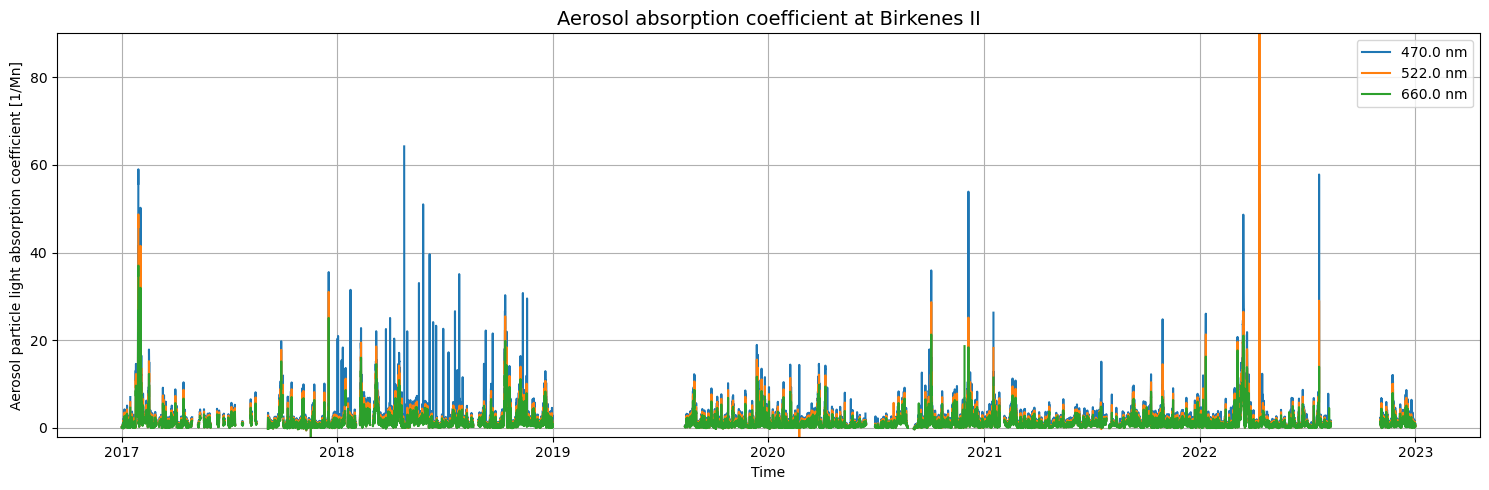

In [9]:
plt.figure(figsize=(15, 5))

for wavelength in abs_ds.Wavelength.values:
    plt.plot(
        abs_ds.time,
        abs_ds.aerosol_absorption_coefficient_amean.sel(Wavelength=wavelength),
        label=f"{wavelength} nm",
    )
plt.title(f"Aerosol absorption coefficient at Birkenes II", fontsize=14)
plt.ylabel("Aerosol particle light absorption coefficient [1/Mn]")
plt.legend()
plt.grid()
plt.ylim([-2, 90])
plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [50]:
# Combine datasets for each instrument model into separate xarray Datasets
instrument_models = ['Radiance-Research/PSAP-3W', 'Radiance-Research/PSAP-1W', 'Magee/AE33']
combined_datasets = {}

for model in instrument_models:
    datasets = []
    for f in metadata_archive:
        if f['md_actris_specific']['instrument_model'] == model:
            dataset_url = f['md_distribution_information'][1]['dataset_url']
            ds = xr.open_dataset(dataset_url)  # Open the dataset

            # Drop all variables with '_qc' in their names to avoid conflicts
            variables_to_drop = [var for var in ds.data_vars if '_qc' in var]
            ds = ds.drop_vars(variables_to_drop)

            datasets.append(ds)  # Append to the list

    # Merge all datasets for the current instrument model into one xarray Dataset
    if datasets:
        combined_datasets[model] = xr.concat(datasets, dim='time', coords='minimal')

# Access the combined datasets for each instrument model
combined_psap_3w = combined_datasets.get('Radiance-Research/PSAP-3W')
combined_psap_1w = combined_datasets.get('Radiance-Research/PSAP-1W')
combined_magee_ae33 = combined_datasets.get('Magee/AE33')

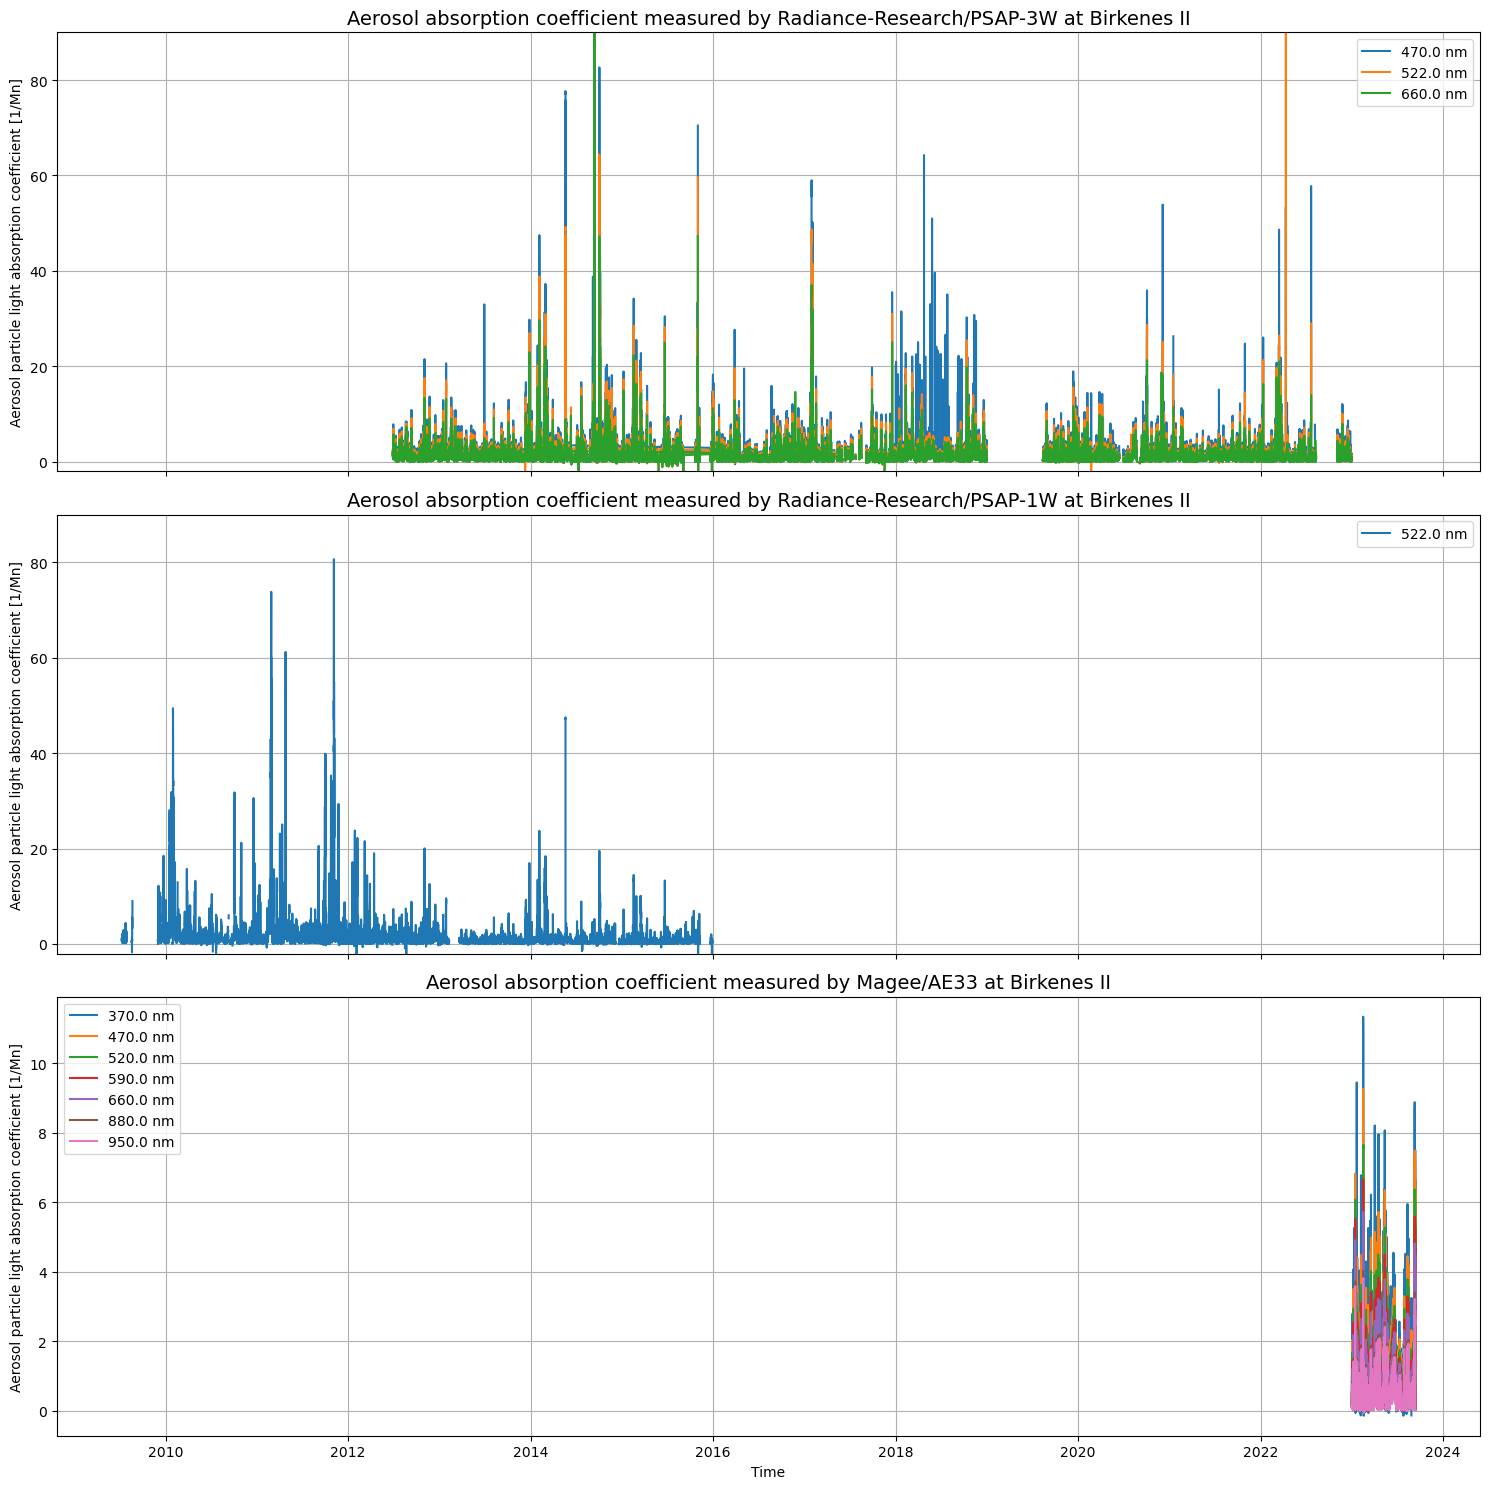

In [51]:
# Define the datasets and their titles
datasets = [
    (combined_psap_3w, "Radiance-Research/PSAP-3W"),
    (combined_psap_1w, "Radiance-Research/PSAP-1W"),
    (combined_magee_ae33, "Magee/AE33"),
]

# Create subplots
fig, axes = plt.subplots(len(datasets), 1, figsize=(15, 15), sharex=True)

for ax, (dataset, model) in zip(axes, datasets):
    if dataset is not None:
        for wavelength in dataset.Wavelength.values:
            ax.plot(
                dataset.time,
                dataset.aerosol_absorption_coefficient_amean.sel(Wavelength=wavelength),
                label=f"{wavelength} nm",
            )
        ax.set_title(f"Aerosol absorption coefficient measured by {model} at Birkenes II", fontsize=14)
        ax.set_ylabel("Aerosol particle light absorption coefficient [1/Mn]")
        ax.legend()
        ax.grid()
        
        # Set y-axis limits for specific datasets 
        if model == "Radiance-Research/PSAP-3W" or model == "Radiance-Research/PSAP-1W":
            ax.set_ylim([-2, 90])

# Set common x-axis label
axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()


In [52]:
# Iterate over each dataset and calculate the mean value for each wavelength
for dataset, model in datasets:
    if dataset is not None:
        print(f"Dataset: {model}")
        for wavelength in dataset.Wavelength.values:
            mean_value = dataset.aerosol_absorption_coefficient_amean.sel(Wavelength=wavelength).mean().item()
            print(f"  Wavelength: {wavelength} nm, Mean Value: {mean_value} 1/Mn")


Dataset: Radiance-Research/PSAP-3W
  Wavelength: 470.0 nm, Mean Value: 1.8274300057948591 1/Mn
  Wavelength: 522.0 nm, Mean Value: 1.5434800217991433 1/Mn
  Wavelength: 660.0 nm, Mean Value: 1.2198786288308203 1/Mn
Dataset: Radiance-Research/PSAP-1W
  Wavelength: 522.0 nm, Mean Value: 1.5958646797115725 1/Mn
Dataset: Magee/AE33
  Wavelength: 370.0 nm, Mean Value: 1.347464178607131 1/Mn
  Wavelength: 470.0 nm, Mean Value: 1.1046651116294566 1/Mn
  Wavelength: 520.0 nm, Mean Value: 0.930824725091636 1/Mn
  Wavelength: 590.0 nm, Mean Value: 0.8052265911362879 1/Mn
  Wavelength: 660.0 nm, Mean Value: 0.6879623458847051 1/Mn
  Wavelength: 880.0 nm, Mean Value: 0.48494335221592805 1/Mn
  Wavelength: 950.0 nm, Mean Value: 0.4604431856047984 1/Mn


In [53]:
first_time = pd.to_datetime(combined_psap_3w.time.min().item())
last_time = pd.to_datetime(combined_psap_3w.time.max().item())

print(f"First time: {first_time.strftime('%Y-%m-%d')}")
print(f"Last time: {last_time.strftime('%Y-%m-%d')}")

First time: 2012-06-27
Last time: 2022-12-31


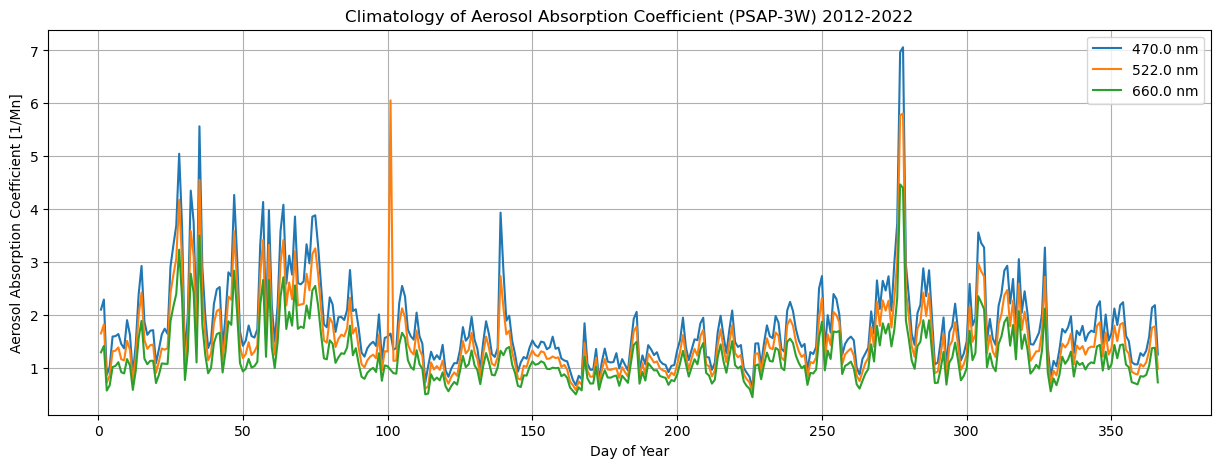

In [54]:
# Extract the dataset for PSAP-3W
psap_3w_ds = combined_psap_3w

# Convert the time coordinate to a pandas datetime index for easier manipulation
time_index = pd.to_datetime(psap_3w_ds.time.values)

# Add a new coordinate for the day of the year to the dataset
psap_3w_ds = psap_3w_ds.assign_coords(day_of_year=("time", time_index.day_of_year))

# Group the data by the day of the year and calculate the mean for each day
climatology = psap_3w_ds.aerosol_absorption_coefficient_amean.groupby("day_of_year").mean(dim="time")

# Plot the climatology
plt.figure(figsize=(15, 5))
for wavelength in psap_3w_ds.Wavelength.values:
    plt.plot(
        climatology.day_of_year,
        climatology.sel(Wavelength=wavelength),
        label=f"{wavelength} nm",
    )

plt.xlabel("Day of Year")
plt.ylabel("Aerosol Absorption Coefficient [1/Mn]")
plt.title("Climatology of Aerosol Absorption Coefficient (PSAP-3W) 2012-2022")
plt.legend()
plt.grid()
plt.show()


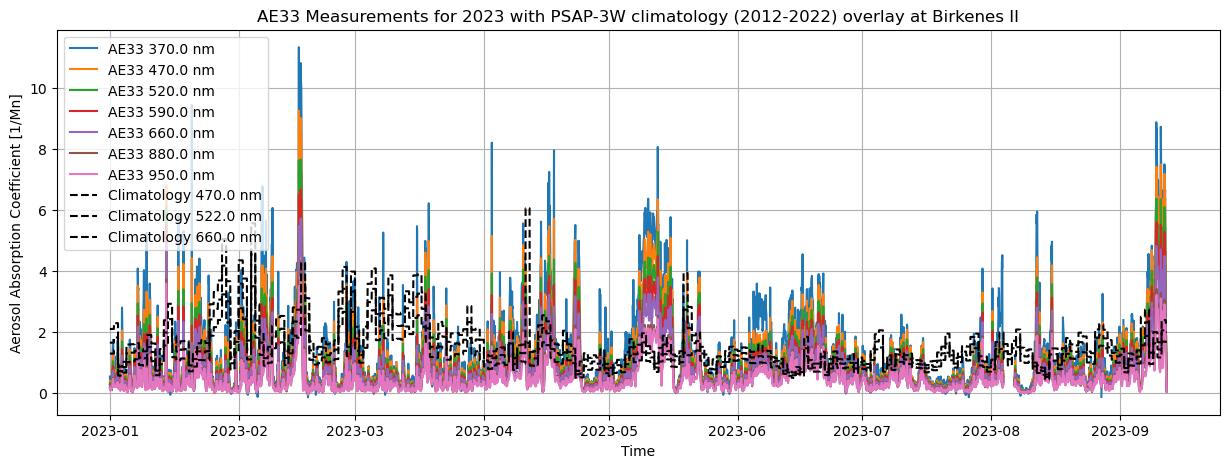

In [106]:
# Ensure the time coordinate is a pandas DatetimeIndex
combined_magee_ae33 = combined_magee_ae33.assign_coords(time=pd.to_datetime(combined_magee_ae33.time.values))

# Align climatology to start from 2023
climatology_for_year = climatology.sel(day_of_year=combined_magee_ae33.time.dt.dayofyear)

# Ensure the time coordinate in climatology_for_year is sorted
climatology_for_year = climatology_for_year.sortby("time")

# Plot the AE33 measurements and overlay the climatology
plt.figure(figsize=(15, 5))

# Plot AE33 measurements
for wavelength in combined_magee_ae33.Wavelength.values:
    plt.plot(
        combined_magee_ae33.time,
        combined_magee_ae33["aerosol_absorption_coefficient_amean"].sel(Wavelength=wavelength),
        label=f"AE33 {wavelength} nm",
    )

# Overlay climatology with black stippled lines
for wavelength in climatology.Wavelength.values:
    plt.plot(
        climatology_for_year.time.sel(time=slice("2023-01-01T00:00:00", "2023-09-12T05:30:00")),
        climatology_for_year.sel(Wavelength=wavelength).sel(time=slice("2023-01-01T00:00:00", "2023-09-12T05:30:00")),
        label=f"Climatology {wavelength} nm",
        linestyle="--",
        color="black",
    )

# Add labels, legend, and title
plt.xlabel("Time")
plt.ylabel("Aerosol Absorption Coefficient [1/Mn]")
plt.title("AE33 Measurements for 2023 with PSAP-3W climatology (2012-2022) overlay at Birkenes II")
plt.legend()
plt.grid()
plt.show()
